In [95]:
# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

FilePath ='/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab ='Apoptosis'
Data = pd.read_excel(io=FilePath,sheet_name=Tab,header=None)

Data

,0,1,2,3,4
0,Gene ID,CT1,CT2,RTX1,RTX2
1,Jun,1809.486005,6842.011346,1602.120022,1358.393282
2,Lmna,1098.670441,1143.036969,1666.449103,2192.656215
3,Fos,7955.665699,15562.711242,6808.078102,4740.668535
4,Ctsd,1551.493957,1436.939419,1911.757292,2153.371012
5,Actb,4123.350063,3248.337915,4676.23732,4078.190702
6,Actg1,878.803095,764.06353,1259.195523,1086.815917
7,Ctsb,652.7361,838.709895,1111.6282,1371.470325


In [96]:
Data.index = Data.iloc[:,0]
Data.columns = Data.iloc[0,:]
Data.index.name = None
Data.columns.name = None

Data

,Gene ID,CT1,CT2,RTX1,RTX2
Gene ID,Gene ID,CT1,CT2,RTX1,RTX2
Jun,Jun,1809.486005,6842.011346,1602.120022,1358.393282
Lmna,Lmna,1098.670441,1143.036969,1666.449103,2192.656215
Fos,Fos,7955.665699,15562.711242,6808.078102,4740.668535
Ctsd,Ctsd,1551.493957,1436.939419,1911.757292,2153.371012
Actb,Actb,4123.350063,3248.337915,4676.23732,4078.190702
Actg1,Actg1,878.803095,764.06353,1259.195523,1086.815917
Ctsb,Ctsb,652.7361,838.709895,1111.6282,1371.470325


In [97]:

# Remove the row and column containing the row and column names
Data = Data.drop('Gene ID',axis=0) # axis=0 means drop a row, axis=1 means drop a column
Data = Data.drop('Gene ID',axis=1)
Data

,CT1,CT2,RTX1,RTX2
Jun,1809.486005,6842.011346,1602.120022,1358.393282
Lmna,1098.670441,1143.036969,1666.449103,2192.656215
Fos,7955.665699,15562.711242,6808.078102,4740.668535
Ctsd,1551.493957,1436.939419,1911.757292,2153.371012
Actb,4123.350063,3248.337915,4676.23732,4078.190702
Actg1,878.803095,764.06353,1259.195523,1086.815917
Ctsb,652.7361,838.709895,1111.6282,1371.470325


In [98]:
Data_transposed = Data.transpose()
Data_transposed

,Jun,Lmna,Fos,Ctsd,Actb,Actg1,Ctsb
CT1,1809.486005,1098.670441,7955.665699,1551.493957,4123.350063,878.803095,652.7361
CT2,6842.011346,1143.036969,15562.711242,1436.939419,3248.337915,764.06353,838.709895
RTX1,1602.120022,1666.449103,6808.078102,1911.757292,4676.23732,1259.195523,1111.6282
RTX2,1358.393282,2192.656215,4740.668535,2153.371012,4078.190702,1086.815917,1371.470325


In [99]:
Data_transposed.loc[:,'Label'] = Data_transposed.index

Data_transposed

,Jun,Lmna,Fos,Ctsd,Actb,Actg1,Ctsb,Label
CT1,1809.486005,1098.670441,7955.665699,1551.493957,4123.350063,878.803095,652.7361,CT1
CT2,6842.011346,1143.036969,15562.711242,1436.939419,3248.337915,764.06353,838.709895,CT2
RTX1,1602.120022,1666.449103,6808.078102,1911.757292,4676.23732,1259.195523,1111.6282,RTX1
RTX2,1358.393282,2192.656215,4740.668535,2153.371012,4078.190702,1086.815917,1371.470325,RTX2


In [100]:

Data_Long= Data_transposed.melt(id_vars='Label',var_name='Gene',value_name='value')
Data_Long
Variable_Values = Data_Long.loc[:,'value']
RowsToKeep = Variable_Values.notna()
Data_Long = Data_Long.loc[RowsToKeep,:]
Data_Long.replace({'CT1': 'CT', 'CT2': 'CT', 'RTX1': 'RTX', 'RTX2': 'RTX'}, inplace=True)
Data_Long


,Label,Gene,value
0,CT,Jun,1809.486005
1,CT,Jun,6842.011346
2,RTX,Jun,1602.120022
3,RTX,Jun,1358.393282
4,CT,Lmna,1098.670441
5,CT,Lmna,1143.036969
6,RTX,Lmna,1666.449103
7,RTX,Lmna,2192.656215
8,CT,Fos,7955.665699
9,CT,Fos,15562.711242


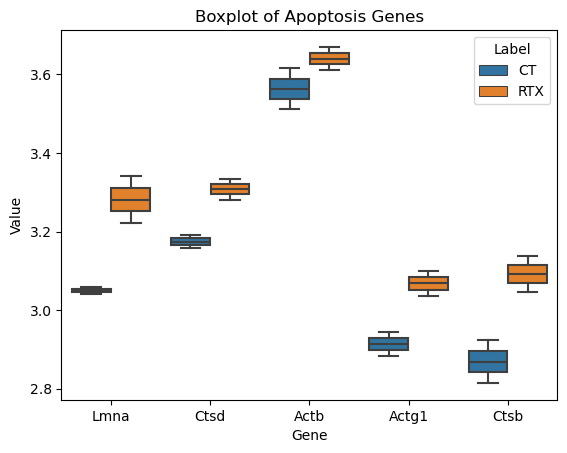

In [101]:
# Assuming 'value' is the column you want to transform
Data_Long['value'] = np.log10(Data_Long['value'])

import seaborn as sns
import matplotlib.pyplot as plt
Data_Long_filtered = Data_Long[Data_Long['Gene'].isin(['Lmna','Actb','Actg1','Ctsd','Ctsb'])]


sns.boxplot(x='Gene', y='value', hue='Label', data=Data_Long_filtered)

# Labeling the graph
plt.xlabel('Gene')
plt.ylabel('Value')
plt.title('Boxplot of Apoptosis Genes')

# Display the graph
plt.show()

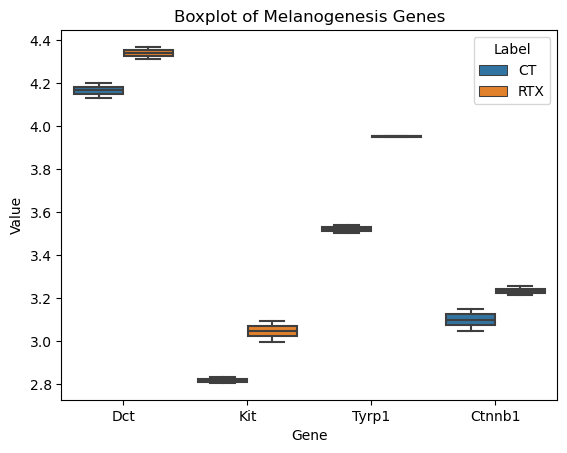

In [102]:
# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

FilePath ='/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab ='Melanogenesis'
Data = pd.read_excel(io=FilePath,sheet_name=Tab,header=None)

Data.index = Data.iloc[:,0]
Data.columns = Data.iloc[0,:]
Data.index.name = None
Data.columns.name = None


# Remove the row and column containing the row and column names
Data = Data.drop('Gene ID',axis=0) # axis=0 means drop a row, axis=1 means drop a column
Data = Data.drop('Gene ID',axis=1)

Data_transposed = Data.transpose()
Data_transposed.loc[:,'Label'] = Data_transposed.index


Data_Long= Data_transposed.melt(id_vars='Label',var_name='Gene',value_name='value')
Data_Long
Variable_Values = Data_Long.loc[:,'value']
RowsToKeep = Variable_Values.notna()
Data_Long = Data_Long.loc[RowsToKeep,:]
Data_Long.replace({'CT1': 'CT', 'CT2': 'CT', 'RTX1': 'RTX', 'RTX2': 'RTX'}, inplace=True)
Data_Long



import numpy as np

# Assuming 'value' is the column you want to transform
Data_Long['value'] = np.log10(Data_Long['value'])
import seaborn as sns
import matplotlib.pyplot as plt
Data_Long_filtered = Data_Long[Data_Long['Gene'].isin(['Ctnnb1','Dct','Tyrp1', 'Kit'])]


# Create boxplot
sns.boxplot(x='Gene', y='value', hue='Label', data=Data_Long_filtered)

# Labeling the graph
plt.xlabel('Gene')
plt.ylabel('Value')
plt.title('Boxplot of Melanogenesis Genes')

# Display the graph
plt.show()

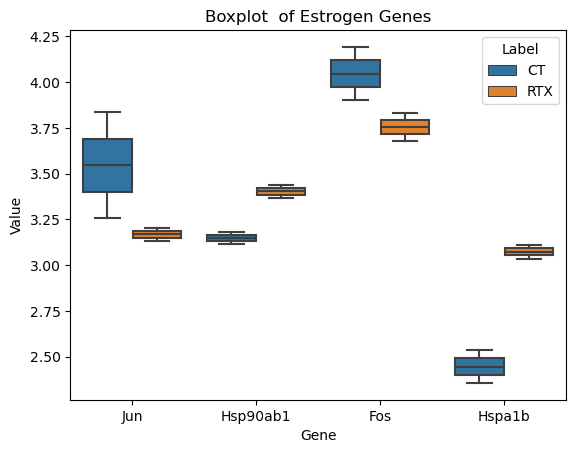

In [103]:
# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

FilePath ='/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab ='Estrogen'
Data = pd.read_excel(io=FilePath,sheet_name=Tab,header=None)

Data.index = Data.iloc[:,0]
Data.columns = Data.iloc[0,:]
Data.index.name = None
Data.columns.name = None


# Remove the row and column containing the row and column names
Data = Data.drop('Gene ID',axis=0) # axis=0 means drop a row, axis=1 means drop a column
Data = Data.drop('Gene ID',axis=1)

Data_transposed = Data.transpose()
Data_transposed.loc[:,'Label'] = Data_transposed.index


Data_Long= Data_transposed.melt(id_vars='Label',var_name='Gene',value_name='value')
Data_Long
Variable_Values = Data_Long.loc[:,'value']
RowsToKeep = Variable_Values.notna()
Data_Long = Data_Long.loc[RowsToKeep,:]
Data_Long.replace({'CT1': 'CT', 'CT2': 'CT', 'RTX1': 'RTX', 'RTX2': 'RTX'}, inplace=True)
Data_Long

import numpy as np

# Assuming 'value' is the column you want to transform
Data_Long['value'] = np.log10(Data_Long['value'])

import seaborn as sns
import matplotlib.pyplot as plt
Data_Long_filtered = Data_Long[Data_Long['Gene'].isin(['Fos', 'Jun', 'Hsp90ab1', 'Hspa1b'])]


sns.boxplot(x='Gene', y='value', hue='Label', data=Data_Long_filtered)

# Labeling the graph
plt.xlabel('Gene')
plt.ylabel('Value')
plt.title('Boxplot  of Estrogen Genes')

# Display the graph
plt.show()

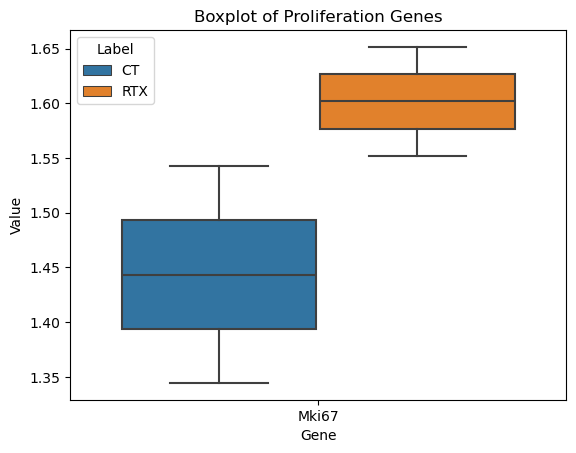

In [104]:
# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

FilePath ='/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab ='Proliferation'
Data = pd.read_excel(io=FilePath,sheet_name=Tab,header=None)

Data.index = Data.iloc[:,0]
Data.columns = Data.iloc[0,:]
Data.index.name = None
Data.columns.name = None

# Remove the row and column containing the row and column names
Data = Data.drop('Gene ID',axis=0) # axis=0 means drop a row, axis=1 means drop a column
Data = Data.drop('Gene ID',axis=1)

Data_transposed = Data.transpose()
Data_transposed.loc[:,'Label'] = Data_transposed.index


Data_Long= Data_transposed.melt(id_vars='Label',var_name='Gene',value_name='value')
Data_Long
Variable_Values = Data_Long.loc[:,'value']
RowsToKeep = Variable_Values.notna()
Data_Long = Data_Long.loc[RowsToKeep,:]
Data_Long.replace({'CT1': 'CT', 'CT2': 'CT', 'RTX1': 'RTX', 'RTX2': 'RTX'}, inplace=True)
Data_Long


import numpy as np

# Assuming 'value' is the column you want to transform
Data_Long['value'] = np.log10(Data_Long['value'])

import seaborn as sns
import matplotlib.pyplot as plt

Data_Long_filtered = Data_Long[Data_Long['Gene'].isin(['Mki67'])]

# Create barplot
sns.boxplot(x='Gene', y='value', hue='Label', data=Data_Long_filtered)

# Labeling the graph
plt.xlabel('Gene')
plt.ylabel('Value')
plt.title('Boxplot of Proliferation Genes')

# Display the graph
plt.show()

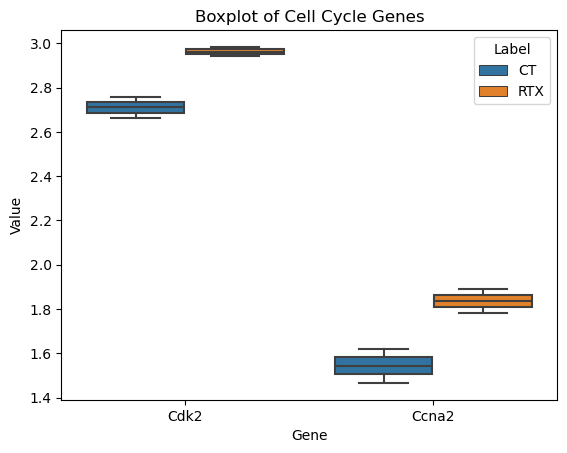

In [105]:
# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

FilePath ='/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab ='Cell Cycle'
Data = pd.read_excel(io=FilePath,sheet_name=Tab,header=None)

Data.index = Data.iloc[:,0]
Data.columns = Data.iloc[0,:]
Data.index.name = None
Data.columns.name = None

# Remove the row and column containing the row and column names
Data = Data.drop('Gene ID',axis=0) # axis=0 means drop a row, axis=1 means drop a column
Data = Data.drop('Gene ID',axis=1)

Data_transposed = Data.transpose()
Data_transposed.loc[:,'Label'] = Data_transposed.index


Data_Long= Data_transposed.melt(id_vars='Label',var_name='Gene',value_name='value')
Data_Long
Variable_Values = Data_Long.loc[:,'value']
RowsToKeep = Variable_Values.notna()
Data_Long = Data_Long.loc[RowsToKeep,:]
Data_Long.replace({'CT1': 'CT', 'CT2': 'CT', 'RTX1': 'RTX', 'RTX2': 'RTX'}, inplace=True)
Data_Long


import numpy as np

# Assuming 'value' is the column you want to transform
Data_Long['value'] = np.log10(Data_Long['value'])

import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(x='Gene', y='value', hue='Label', data=Data_Long)

# Labeling the graph
plt.xlabel('Gene')
plt.ylabel('Value')
plt.title('Boxplot of Cell Cycle Genes')

# Display the graph
plt.show()

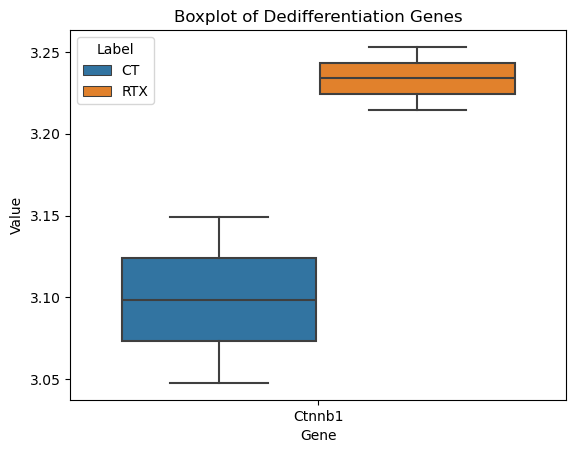

In [106]:
# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

FilePath ='/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab ='Dedifferentiation'
Data = pd.read_excel(io=FilePath,sheet_name=Tab,header=None)

Data.index = Data.iloc[:,0]
Data.columns = Data.iloc[0,:]
Data.index.name = None
Data.columns.name = None

# Remove the row and column containing the row and column names
Data = Data.drop('Gene ID',axis=0) # axis=0 means drop a row, axis=1 means drop a column
Data = Data.drop('Gene ID',axis=1)

Data_transposed = Data.transpose()
Data_transposed.loc[:,'Label'] = Data_transposed.index


Data_Long= Data_transposed.melt(id_vars='Label',var_name='Gene',value_name='value')
Data_Long
Variable_Values = Data_Long.loc[:,'value']
RowsToKeep = Variable_Values.notna()
Data_Long = Data_Long.loc[RowsToKeep,:]
Data_Long.replace({'CT1': 'CT', 'CT2': 'CT', 'RTX1': 'RTX', 'RTX2': 'RTX'}, inplace=True)
Data_Long


import numpy as np

# Assuming 'value' is the column you want to transform
Data_Long['value'] = np.log10(Data_Long['value'])

import seaborn as sns
import matplotlib.pyplot as plt

# Create barplot
sns.boxplot(x='Gene', y='value', hue='Label', data=Data_Long)

# Labeling the graph
plt.xlabel('Gene')
plt.ylabel('Value')
plt.title('Boxplot of Dedifferentiation Genes')

# Display the graph
plt.show()